<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t042_molt5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MolT5 — 분자와 자연어 사이를 번역하는 모델

**Day 06 · LLM 활용 & 신약개발 실습**

분자 설명문(자연어)과 SMILES(분자 구조 문자열)를 **양방향으로 번역**하는 MolT5를 직접 돌려 보고,
같은 문제를 2022·2024·2026년 세 세대의 모델에 던져 **무엇이 달라졌는지**를 한 화면에서 비교한다.

## 0. 실행 환경

- **Colab에서 바로 실행됩니다.** GPU(T4)를 켜면 빠르지만, **CPU 런타임에서도 동작**합니다.
- 이 노트북은 `molt5-large` 모델 **2종(caption2smiles, smiles2caption)** 을 내려받습니다. 각각 약 3GB이므로
  첫 실행 시 다운로드에 수 분이 걸립니다. Hugging Face 로그인이나 라이선스 동의는 **필요 없습니다**.
- 생성 시간(참고): CPU 기준 프롬프트 1개당 약 15초, GPU에서는 1~2초.
- 아래 셀이 필요한 패키지를 먼저 확인해 **없는 것만** 설치하고, 연산 장치를 `DEVICE` 상수 하나로 고정합니다.
  이후 모든 셀은 `DEVICE` 만 참조합니다.

In [1]:
import importlib, subprocess, sys

REQUIRED = {
    # "import 이름": "pip 패키지명"
    "transformers": "transformers",      # T5 계열 모델/토크나이저
    "rdkit": "rdkit",                    # SMILES 파싱 및 분자 그림
    "sentencepiece": "sentencepiece",    # T5Tokenizer 가 요구하는 토크나이저 백엔드
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


import torch

# 연산 장치는 이 상수 하나로 고정한다 (노트북 전체에서 DEVICE 만 사용)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("DEVICE =", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("[안내] CPU 런타임입니다. 실행은 되지만 molt5-large 생성이 프롬프트당 약 15초로 느려지고,")
    print("       9절의 8B 모델(ChemDFM, 4-bit 양자화)은 GPU가 없으므로 자동으로 건너뜁니다.")


모든 의존 패키지가 이미 준비되어 있습니다.


PyTorch: 2.13.0+cpu
DEVICE = cpu
[안내] CPU 런타임입니다. 실행은 되지만 molt5-large 생성이 프롬프트당 약 15초로 느려지고,
       9절의 8B 모델(ChemDFM, 4-bit 양자화)은 GPU가 없으므로 자동으로 건너뜁니다.


## 1. 개요와 학습 목표

MolT5는 T5 (Text-To-Text Transfer Transformer) 아키텍처를 기반으로 한 분자 언어모델로, 다양한 화학정보학(Cheminformatics) 작업을 처리하기 위해 설계되었습니다. 이 모델은 분자 설명을 SMILES(분자 구조를 표현하는 문자열 형식), IUPAC 이름, 분자 특성 등의 다양한 표현으로 변환할 수 있습니다. MolT5는 화학 언어와 구조화된 분자 데이터 간의 복잡한 매핑을 학습하는 능력 덕분에 신약 개발과 화학정보학 분야에서 중요한 도구로 활용될 수 있습니다.

MolT5의 원 논문은 Edwards et al., **"Translation between Molecules and Natural Language"** (EMNLP 2022, arXiv:2204.11817) 입니다.
대량의 무표지(unlabeled) SMILES와 텍스트로 T5를 사전학습한 뒤, ChEBI-20 데이터셋으로
**molecule captioning(분자 → 설명)** 과 **text-based de novo molecule generation(설명 → 분자)** 두 과제를 미세조정한 모델입니다.
공개 체크포인트가 `laituan245/molt5-*` 이며, 이 노트북에서는 그 중 `-large` 두 종을 사용합니다.

> ⚠️ 이 노트북의 이전 버전에는 실제로 존재하지 않는 논문 제목이 인용되어 있었습니다.
> 생성형 모델 실습에서는 **모델 출력뿐 아니라 교재의 인용도 검증 대상**이라는 점을 기억하세요.

### 학습 목표

- **설명 → SMILES** 방향으로 분자를 생성하고, 생성된 문자열을 **RDKit 파싱으로 반드시 검증**한다 (4-6절).
- **SMILES → 설명** 방향으로 캡션을 만들고, 그 설명이 실제 약리작용과 어긋날 수 있음을 확인한다 (7-8절).
- 태스크마다 **별도 체크포인트**가 필요한 전용 번역기의 구조적 제약을 체감한다.
- 같은 문제를 세 세대(전용 번역기 → 화학 지시학습 LLM → 프론티어)에 던져
  **기계적 지표(유효성 · canonical 일치 · Tanimoto · 키워드 적중)** 로만 비교한다 (9절).
- n=1 시연과 벤치마크의 차이를 구분하고, 결과를 과장하지 않는 서술 방식을 익힌다.

## 2. 라이브러리 가져오기

In [2]:
# 필요한 라이브러리 가져오기
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration
from rdkit.Chem import Draw
from rdkit import Chem
import pandas as pd  # 여러 분자 설명을 처리하기 위한 라이브러리
from IPython.display import display  # Colab에서 이미지를 표시하기 위한 라이브러리

# 연산 장치는 0절에서 정의한 DEVICE 상수를 그대로 쓴다 (재정의하지 않는다)
print("DEVICE =", DEVICE)

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu


## 3. MolT5 모델과 토크나이저 로드하기

In [3]:
# MolT5 모델과 토크나이저 로드
# molt5-large 는 약 3GB 입니다. 첫 실행 시 다운로드에 수 분 걸릴 수 있습니다.
tokenizer = T5Tokenizer.from_pretrained("laituan245/molt5-large-caption2smiles", model_max_length=512)
model = T5ForConditionalGeneration.from_pretrained("laituan245/molt5-large-caption2smiles").to(DEVICE).eval()
print("caption2smiles 모델 로드 완료 (DEVICE =", DEVICE, ")")

Loading weights:   0%|          | 0/560 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 560/560 [00:00<00:00, 14239.53it/s]


[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


caption2smiles 모델 로드 완료 (DEVICE = cpu )


## 4. 하나의 텍스트 설명을 분자로 변환하기

생성된 SMILES: CC(C)(C)C1=CC=C(C=C1)CC(C)(C)NCC(C2=CC(=C(C=C2)F)F)O
RDKit 파싱 성공 - 유효한 SMILES 입니다. Canonical: CC(C)(Cc1ccc(C(C)(C)C)cc1)NCC(O)c1ccc(F)c(F)c1


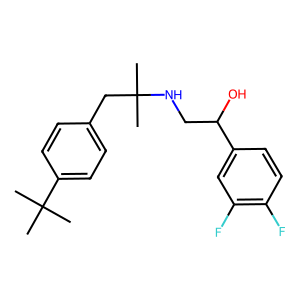

In [4]:
# 분자에 대한 텍스트 설명 입력 (PDE5 저해제 예시: 실데나필/sildenafil)
input_text = 'The molecule is sildenafil, a selective phosphodiesterase type 5 (PDE5) inhibitor used to treat erectile dysfunction and pulmonary arterial hypertension.'

# 설명을 SMILES로 변환
inputs = tokenizer.encode(input_text, return_tensors="pt").to(DEVICE)
output_ids = model.generate(inputs, max_length=512)
smiles = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("생성된 SMILES:", smiles)

# RDKit 파싱으로 유효성 검사 후 시각화
mol = Chem.MolFromSmiles(smiles)
if mol:
    print("RDKit 파싱 성공 - 유효한 SMILES 입니다. Canonical:", Chem.MolToSmiles(mol))
    display(Draw.MolToImage(mol, size=(300, 300)))
else:
    print("유효한 분자를 생성할 수 없습니다 (RDKit 파싱 실패).")

# [9절 '세 세대 비교'에서 재사용] 이 셀의 결과를 별도 변수에 보관 (아래 6절에서 smiles 가 덮어써지므로)
MOLT5_CAPTION2SMILES_OUT = smiles

> **모델의 한계에 대한 안내**
>
> MolT5는 "설명 → SMILES"를 학습한 모델일 뿐, 화합물 데이터베이스를 조회하는 것이 아닙니다.
> 따라서 "sildenafil" 이라고 이름을 주어도 **실제 실데나필 구조가 나오지 않는 경우가 대부분**입니다.
> 이 실습의 목적은 정답 구조를 얻는 것이 아니라, (1) 생성 모델이 화학 문자열을 만들어낸다는 점과
> (2) **생성 결과는 반드시 RDKit 파싱으로 검증해야 한다**는 점을 확인하는 것입니다.
> 실제 구조는 아래 7절에서 정답 SMILES를 직접 넣어 확인합니다.

## 5. 여러 개의 분자 설명을 일괄 처리

,Description,SMILES,Valid,Canonical
0,A benzene ring substituted with a nitro group ...,C1=CC=C(C(=C1)[N+](=O)[O-])O,True,O=[N+]([O-])c1ccccc1O
1,A molecule consisting of a six-membered ring w...,C1=CC(=C(C=C1O)O)O,True,Oc1ccc(O)c(O)c1
2,An aliphatic compound containing a methyl grou...,CCC(C)(C)C,True,CCC(C)(C)C


유효 SMILES: 3 / 3


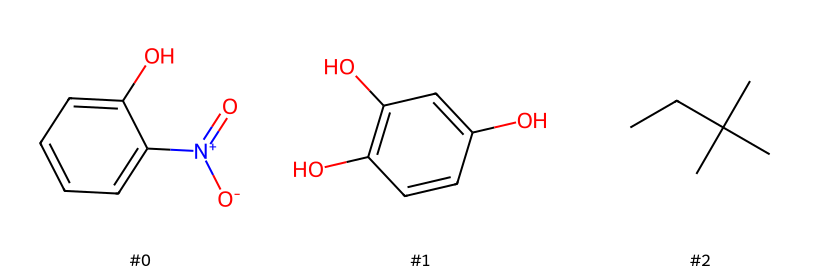

In [5]:
# 여러 개의 분자 설명 예시
descriptions = [
    'A benzene ring substituted with a nitro group at position 1 and a hydroxyl group at position 2.',
    'A molecule consisting of a six-membered ring with two hydroxyl groups at positions 1 and 3.',
    'An aliphatic compound containing a methyl group at the first carbon and an ethyl group at the second carbon.'
]

# 여러 설명을 처리하기 위한 DataFrame 생성
df = pd.DataFrame(descriptions, columns=['Description'])
df['SMILES'] = ''

# 각 설명에 대해 SMILES 생성
for idx, desc in enumerate(df['Description']):
    inputs = tokenizer.encode(desc, return_tensors="pt").to(DEVICE)
    output_ids = model.generate(inputs, max_length=512)
    df.at[idx, 'SMILES'] = tokenizer.decode(output_ids[0], skip_special_tokens=True)

# 생성된 SMILES 전부에 대해 RDKit 파싱 유효성 검사
df['Valid'] = [Chem.MolFromSmiles(s) is not None for s in df['SMILES']]
df['Canonical'] = [Chem.MolToSmiles(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else None
                   for s in df['SMILES']]

# DataFrame 표시
display(df)
print(f"유효 SMILES: {int(df['Valid'].sum())} / {len(df)}")

# 유효한 분자만 그리드로 시각화
valid_mols = [Chem.MolFromSmiles(s) for s, v in zip(df['SMILES'], df['Valid']) if v]
if valid_mols:
    display(Draw.MolsToGridImage(valid_mols,
                                 legends=[f"#{i}" for i, v in enumerate(df['Valid']) if v],
                                 molsPerRow=3, subImgSize=(280, 280)))

## 6. 에러 처리 및 시각화

생성된 SMILES: [H+].[H+].CC1=CC=C(C=C1)N
RDKit 파싱 성공: Cc1ccc(N)cc1.[H+].[H+]


[15:36:44] WARNING: not removing hydrogen atom without neighbors
[15:36:44] WARNING: not removing hydrogen atom without neighbors


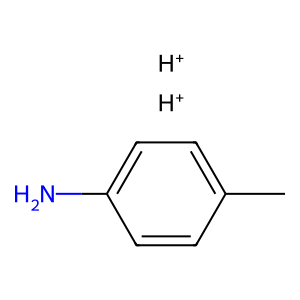

In [6]:
# 분자를 시각화하는 함수 (RDKit 파싱 유효성 검사 포함)
def visualize_molecule(smiles):
    """SMILES를 RDKit으로 파싱해 유효하면 2D 구조를 그린다."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            print("RDKit 파싱 성공:", Chem.MolToSmiles(mol))
            display(Draw.MolToImage(mol, size=(300, 300)))
        else:
            print(f"유효하지 않은 SMILES: {smiles}")
    except Exception as e:
        print(f"오류: {e}")

# 에러 처리가 포함된 예시 (의도적으로 모호한 설명을 넣습니다)
input_text = 'A molecule with an invalid description.'
inputs = tokenizer.encode(input_text, return_tensors="pt").to(DEVICE)
output_ids = model.generate(inputs, max_length=512)
smiles = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("생성된 SMILES:", smiles)

# 에러 처리를 포함한 시각화
visualize_molecule(smiles)

## 7. SMILES를 설명으로 변환하기

Loading weights:   0%|          | 0/560 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 560/560 [00:00<00:00, 13439.51it/s]


[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


입력 SMILES 유효성: True


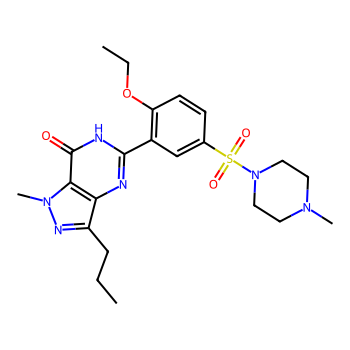

생성된 설명: The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degenerative joint disease. It has a role as a non-steroidal anti-inflammatory drug, a cyclooxygenase 2 inhibitor and a non-narcotic analgesic. It is a member of pyrazoles, an organic sulfide and a sulfonamide.

[안내] MolT5가 만든 설명이 실제 실데나필 약리작용과 다를 수 있습니다.
       생성형 모델의 설명은 근거 문헌으로 반드시 교차검증해야 합니다.


In [7]:
# SMILES를 설명으로 변환하기 위한 모델 로드 (약 3GB, 첫 실행 시 다운로드)
tokenizer_caption = T5Tokenizer.from_pretrained("laituan245/molt5-large-smiles2caption", model_max_length=512)
model_caption = T5ForConditionalGeneration.from_pretrained("laituan245/molt5-large-smiles2caption").to(DEVICE).eval()

# 예시 SMILES 문자열 - 실데나필(비아그라)
smiles_example = "CCCc1nn(C)c2c1nc([nH]c2=O)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"

# 입력 SMILES 자체가 유효한지 먼저 RDKit으로 확인
mol_example = Chem.MolFromSmiles(smiles_example)
print("입력 SMILES 유효성:", mol_example is not None)
display(Draw.MolToImage(mol_example, size=(350, 350)))

inputs = tokenizer_caption.encode(smiles_example, return_tensors="pt").to(DEVICE)
output_ids = model_caption.generate(inputs, max_length=512)
description = tokenizer_caption.decode(output_ids[0], skip_special_tokens=True)

print("생성된 설명:", description)
print()
print("[안내] MolT5가 만든 설명이 실제 실데나필 약리작용과 다를 수 있습니다.")
print("       생성형 모델의 설명은 근거 문헌으로 반드시 교차검증해야 합니다.")

## 8. SMILES 문자열 변형

In [8]:
# 8절에서는 "설명을 바꿔서 유사 구조를 만들어보기"를 해봅니다.
# 먼저 원본 SMILES -> 설명 (smiles2caption)
tokenizer_smiles2caption = tokenizer_caption
model_smiles2caption = model_caption

# 원본 SMILES 예시
original_smiles = "CCCc1nn(C)c2c1nc([nH]c2=O)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"  # 실데나필 (PDE5 저해제)

# SMILES를 설명으로 변환
inputs = tokenizer_smiles2caption.encode(original_smiles, return_tensors="pt").to(DEVICE)
output_ids = model_smiles2caption.generate(inputs, max_length=512)
caption = tokenizer_smiles2caption.decode(output_ids[0], skip_special_tokens=True)

print("SMILES에 대한 설명:", caption)

SMILES에 대한 설명: The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degenerative joint disease. It has a role as a non-steroidal anti-inflammatory drug, a cyclooxygenase 2 inhibitor and a non-narcotic analgesic. It is a member of pyrazoles, an organic sulfide and a sulfonamide.


결합된 설명: The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degenerative joint disease. It has a role as a non-steroidal anti-inflammatory drug, a cyclooxygenase 2 inhibitor and a non-narcotic analgesic. It is a member of pyrazoles, an organic sulfide and a sulfonamide. In this molecule, the N-methyl group on the piperazine ring is replaced by an ethyl group.


변형된 SMILES: CCC1CCC(CC1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C
원본 유효: True / 변형 유효: True


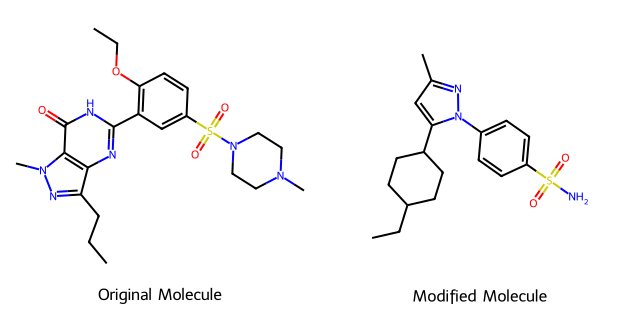

In [9]:
# 변형된 설명 (예: 실데나필의 피페라진 N-메틸기를 에틸기로 치환하는 유사 구조 변형)
modification = "In this molecule, the N-methyl group on the piperazine ring is replaced by an ethyl group."
combined_caption = caption + " " + modification

print("결합된 설명:", combined_caption)

# Caption-to-SMILES 모델은 3절에서 이미 로드했으므로 재사용합니다
tokenizer_caption2smiles = tokenizer
model_caption2smiles = model

# 변형된 설명을 SMILES로 변환
inputs = tokenizer_caption2smiles.encode(combined_caption, return_tensors="pt").to(DEVICE)
output_ids = model_caption2smiles.generate(inputs, max_length=512)
modified_smiles = tokenizer_caption2smiles.decode(output_ids[0], skip_special_tokens=True)

print("변형된 SMILES:", modified_smiles)

# RDKit 파싱 유효성 검사 후 원본과 나란히 시각화
original_mol = Chem.MolFromSmiles(original_smiles)
modified_mol = Chem.MolFromSmiles(modified_smiles)
print("원본 유효:", original_mol is not None, "/ 변형 유효:", modified_mol is not None)

if original_mol and modified_mol:
    img = Draw.MolsToGridImage([original_mol, modified_mol],
                               legends=["Original Molecule", "Modified Molecule"],
                               molsPerRow=2, subImgSize=(320, 320))
    display(img)
else:
    print("원본 또는 변형된 SMILES로부터 유효한 분자를 생성할 수 없습니다.")

## 9. 같은 문제, 세 세대 — 화학 언어모델 3세대 비교

지금까지 본 MolT5는 **2022년의 전용 번역기**입니다. 4절에서 실데나필 설명을 넣었을 때 실데나필이 나오지 않았고,
7절에서 실데나필 SMILES를 넣었을 때 설명도 어긋났습니다. 이건 MolT5가 못 만든 모델이라서가 아니라,
**그 세대의 모델이 할 수 있도록 설계된 일의 범위**가 거기까지였기 때문입니다.

이 절에서는 **완전히 같은 문제 하나**(실데나필, 양방향)를 세 세대의 모델에 똑같이 던져서
무엇이 달라졌는지 직접 확인합니다.

| 세대 | 대표 모델 (실제 Hugging Face ID) | 라이선스 · 크기 | 성격 |
|---|---|---|---|
| **① 전용 번역기 (2022)** | `laituan245/molt5-large-caption2smiles` / `-smiles2caption`<br>(계열: BioT5 `QizhiPei/biot5-base-text2mol`) | Apache-2.0 · 약 3 GB × 2 | T5 encoder-decoder. **태스크 고정**(설명↔SMILES 단방향 번역), 대화 불가, 지시 이해 불가 |
| **② 화학 지시학습 LLM (2024–25)** | `OpenDFM/ChemDFM-v1.5-8B`<br>`AI4Chem/ChemLLM-7B-Chat` | AGPL-3.0 · 16.1 GB (8B)<br>Apache-2.0 · 약 15 GB (7B) | decoder-only LLM에 화학 도메인 사전학습 + 지시학습. **대화·다중 태스크·단계적 추론** 가능 |
| **③ 멀티모달 / 프론티어 (2025–26)** | `AI4Chem/ChemVLM-8B` (image-text-to-text)<br>Gemini · GPT-5 등 상용 프론티어 | Apache-2.0 · 약 16 GB<br>상용 API | 구조 **이미지**를 직접 입력받거나(ChemVLM), 범용 추론력으로 화학 문제를 푸는 초대형 모델 |

**모델 선택에 대한 정직한 고지**

- 위 세 개의 오픈 모델(`ChemDFM-v1.5-8B`, `ChemLLM-7B-Chat`, `ChemVLM-8B`)은 2026-09 기준 **HF에서 공개·비게이팅** 상태임을 실제로 확인했습니다.
- 반면 강의에서 자주 언급되는 **ChemMLLM**, **3D-MoLM** 은 현재 HF 접근이 **게이팅/비공개(HTTP 401)** 라서
  **이 노트북에서 실습할 수 없습니다.** 논문만 읽고 넘어가야 하는 모델입니다. (없는 걸 있는 척하지 않습니다.)
- 세대 ②·③은 **GPU / API 키가 없으면 자동으로 건너뜁니다.** 건너뛴 사실은 결과 표에 그대로 남습니다.


### 9-1. 공통 평가 문제와 채점 규칙

세 세대에 **똑같은 문제**를 줍니다.

- **(a) 설명 → SMILES**: 4절에서 쓴 것과 **글자 그대로 같은** 실데나필 설명문
- **(b) SMILES → 설명**: 7절에서 쓴 것과 **글자 그대로 같은** 실데나필 SMILES

채점은 **기계적으로만** 합니다. 사람이 "설명이 그럴듯한가"를 주관적으로 매기지 않습니다.

| 대상 | 지표 | 계산 방법 |
|---|---|---|
| (a) SMILES | 유효성 | `Chem.MolFromSmiles()` 파싱 성공 여부 |
| (a) SMILES | 정답 일치 | 생성 SMILES의 **canonical form** == 실데나필 canonical form |
| (a) SMILES | Tanimoto | Morgan fingerprint (radius=2, 2048 bit) 유사도 |
| (b) 설명 | 키워드 적중 | `pde5 / phosphodiesterase / erectile / sildenafil / pulmonary` 5개 중 몇 개가 문자열에 등장하는가 |

키워드 적중은 **"정답 여부"가 아니라 "정답의 흔적이 있는가"** 를 보는 아주 거친 프록시입니다.
5개를 다 맞춰도 문장 전체가 틀릴 수 있습니다. 그 한계를 알고 씁니다.

In [10]:
# --- 9-1. 공통 평가 문제 정의 + 기계적 채점 함수 ---
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator
import re
import pandas as pd

# (a) 설명 -> SMILES : 4절과 동일한 문장
TASK_A_PROMPT = ("The molecule is sildenafil, a selective phosphodiesterase type 5 (PDE5) "
                 "inhibitor used to treat erectile dysfunction and pulmonary arterial hypertension.")

# (b) SMILES -> 설명 : 7절과 동일한 실데나필 SMILES
TASK_B_SMILES = "CCCc1nn(C)c2c1nc([nH]c2=O)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"

REF_MOL       = Chem.MolFromSmiles(TASK_B_SMILES)
REF_CANONICAL = Chem.MolToSmiles(REF_MOL)

_MORGAN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
_REF_FP = _MORGAN.GetFingerprint(REF_MOL)

DESC_KEYWORDS = ["pde5", "phosphodiesterase", "erectile", "sildenafil", "pulmonary"]


def score_smiles(smiles):
    """(a) 채점: RDKit 유효성 / 정답 canonical 일치 / Tanimoto(Morgan r=2, 2048bit)."""
    out = {"valid": False, "exact": False, "tanimoto": None, "canonical": None}
    if not smiles:
        return out
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        return out
    can = Chem.MolToSmiles(mol)
    out["valid"]     = True
    out["canonical"] = can
    out["exact"]     = (can == REF_CANONICAL)
    out["tanimoto"]  = round(DataStructs.TanimotoSimilarity(_MORGAN.GetFingerprint(mol), _REF_FP), 3)
    return out


def score_description(text):
    """(b) 채점: 키워드 포함 여부라는 기계적 체크만. 문장 품질은 평가하지 않는다."""
    low  = (text or "").lower()
    hits = [k for k in DESC_KEYWORDS if k in low]
    return {"kw_hits": hits, "kw_score": f"{len(hits)}/{len(DESC_KEYWORDS)}"}


def extract_smiles(text):
    """자유형 LLM 답변에서 SMILES 후보를 기계적으로 추출한다.

    코드블록 -> 공백 구분 토큰 순으로 훑어, RDKit 이 파싱에 성공하는 가장 긴 토큰을 고른다.
    (규칙 기반이며 추측이나 보정을 하지 않는다. 못 찾으면 None.)
    """
    if not text:
        return None
    candidates = re.findall(r"```(?:\w+)?\s*(.*?)```", text, flags=re.S)
    candidates += re.split(r"[\s`\n]+", text)
    best = None
    for c in candidates:
        c = c.strip().strip(".,;:()[]'\"")
        if len(c) < 8 or " " in c:
            continue
        if Chem.MolFromSmiles(c) is not None:
            if best is None or len(c) > len(best):
                best = c
    return best


RESULTS = []  # 세대별 결과 누적 (표/그림의 유일한 소스)


def register(generation, model_id, smiles_out, desc_out, status="실행", note=""):
    """결과를 RESULTS 에 기록. 실행하지 않은 세대는 0점이 아니라 '-' 로 남긴다."""
    ran = (smiles_out is not None) or (desc_out is not None)
    if ran:
        s = score_smiles(smiles_out)
        d = score_description(desc_out)
        row_valid, row_exact = s["valid"], s["exact"]
        row_tani, row_can    = s["tanimoto"], s["canonical"]
        row_kw, row_hits     = d["kw_score"], ",".join(d["kw_hits"])
    else:  # 미실행/SKIP — 채점하지 않는다
        row_valid = row_exact = row_tani = row_can = row_kw = row_hits = "-"
    RESULTS.append({
        "세대": generation, "모델": model_id, "상태": status,
        "생성 SMILES": smiles_out, "SMILES 유효": row_valid, "정답 일치": row_exact,
        "Tanimoto": row_tani, "canonical": row_can,
        "설명 출력": desc_out, "설명 키워드": row_kw, "적중 키워드": row_hits,
        "비고": note,
    })
    print(f"[{generation}] {model_id} ({status})")
    if ran:
        print(f"  (a) 생성 SMILES : {smiles_out}")
        print(f"      유효={row_valid}  정답일치={row_exact}  Tanimoto={row_tani}")
        print(f"  (b) 설명 키워드 : {row_kw}  {row_hits}")
    else:
        print("  실행하지 않았으므로 채점하지 않습니다 (표에는 '-' 로 남습니다).")
    print()


print("정답 실데나필 canonical SMILES:", REF_CANONICAL)
print("과제 (a) 프롬프트 길이:", len(TASK_A_PROMPT), "자")
print("채점 함수 준비 완료 — score_smiles / score_description / extract_smiles")

정답 실데나필 canonical SMILES: CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12
과제 (a) 프롬프트 길이: 153 자
채점 함수 준비 완료 — score_smiles / score_description / extract_smiles


### 9-2. 세대 ① — MolT5 (2022, 전용 번역기)

**앞 절에서 이미 생성한 결과를 그대로 가져다 씁니다. 모델을 다시 돌리지 않습니다.**

- (a) 는 4절의 `MOLT5_CAPTION2SMILES_OUT`
- (b) 는 7절의 `description`

MolT5는 대화를 못 하므로 "설명해줘" 같은 지시를 줄 수 없고, 두 방향에 **별도의 체크포인트 2개**가 필요했다는 점도
표에 함께 기록합니다.

In [11]:
# --- 9-2. 세대 ① MolT5 결과 재사용 (재실행하지 않음) ---
missing = [v for v in ("MOLT5_CAPTION2SMILES_OUT", "description") if v not in globals()]
if missing:
    raise RuntimeError(
        f"앞 절의 변수 {missing} 가 없습니다. 4절과 7절 셀을 먼저 실행한 뒤 이 셀을 실행하세요."
    )

register(
    generation="① 전용 번역기 (2022)",
    model_id="laituan245/molt5-large-{caption2smiles, smiles2caption}",
    smiles_out=MOLT5_CAPTION2SMILES_OUT,   # 4절 출력
    desc_out=description,                  # 7절 출력
    status="실행",
    note="태스크별 체크포인트 2개 필요 · 대화 불가",
)

[① 전용 번역기 (2022)] laituan245/molt5-large-{caption2smiles, smiles2caption} (실행)
  (a) 생성 SMILES : CC(C)(C)C1=CC=C(C=C1)CC(C)(C)NCC(C2=CC(=C(C=C2)F)F)O
      유효=True  정답일치=False  Tanimoto=0.063
  (b) 설명 키워드 : 0/5  



### 9-3. 세대 ② — ChemDFM-v1.5-8B (2024, 화학 지시학습 LLM)

> ⚠️ **먼저 읽어주세요 — 자원 경고**
> - `OpenDFM/ChemDFM-v1.5-8B` 는 safetensors 4개, **총 약 16.1 GB** 를 내려받습니다. Colab 기준 **10분 내외**가 걸립니다.
> - 4-bit 양자화(`bitsandbytes`)로 올리면 VRAM 사용량은 **약 5.5 GB** 이므로 **T4 16GB에서 동작**합니다.
> - **GPU가 없으면 이 셀은 자동으로 건너뜁니다.** CPU에서 8B 모델을 강행하지 않습니다(수십 분~시간 단위).
> - 라이선스는 **AGPL-3.0** 입니다. 사내 도입 전 라이선스 검토가 필요합니다.

**프롬프트 템플릿은 추측하지 않고 모델 카드에서 확인한 것을 씁니다.**
ChemDFM 모델 카드가 명시한 형식은 다음과 같습니다.

```
[Round 0]
Human: {질문}
Assistant:
```

`tokenizer_config.json` 에는 LLaMA-3 계열에서 상속된 `chat_template` 도 **존재**하지만,
모델 카드는 **instruction tuning 때 실제로 쓴 형식이 위의 `[Round N]` 포맷**이라고 안내합니다.
아래 셀은 `apply_chat_template` 지원 여부를 **먼저 검사해 출력한 뒤**, 모델 카드가 권장한 `[Round N]` 포맷을 사용합니다.

또한 카드의 권고대로 입력 SMILES는 RDKit으로 **canonical 화**해서 넣습니다.

In [12]:
# --- 9-3. 세대 ② ChemDFM-v1.5-8B (GPU 없으면 자동 skip) ---
import os
import torch

CHEMDFM_ID = "OpenDFM/ChemDFM-v1.5-8B"   # HF 실재 확인 (public, text-generation, safetensors 4 shards)

def format_chemdfm(current_query, history=()):
    """ChemDFM 모델 카드가 명시한 대화 템플릿. 추측이 아니라 카드 원문 그대로."""
    s = ""
    for idx, (q, a) in enumerate(history):
        s += f"[Round {idx}]\nHuman: {q}\nAssistant: {a}\n"
    s += f"[Round {len(history)}]\nHuman: {current_query}\nAssistant:"
    return s

# 카드 권고: SMILES 는 RDKit 으로 canonical 화해서 입력
_q_a = f"Please give the SMILES string of the molecule described below.\n{TASK_A_PROMPT}"
_q_b = f"Can you please give detailed descriptions of the molecule below?\n{Chem.CanonSmiles(TASK_B_SMILES)}"

print("[템플릿 미리보기]")
print(format_chemdfm(_q_a)[:300], "...\n")

if not torch.cuda.is_available():
    print("=" * 72)
    print("[SKIP] GPU를 찾지 못했습니다 (torch.cuda.is_available() == False).")
    print("       8B 모델을 CPU에서 강행하지 않습니다. 세대 ②는 건너뜁니다.")
    print("       Colab: 런타임 > 런타임 유형 변경 > 하드웨어 가속기 > T4 GPU 로 바꾼 뒤 재실행하세요.")
    print("=" * 72)
    register("② 화학 지시학습 LLM (2024)", CHEMDFM_ID,
             smiles_out=None, desc_out=None, status="SKIP (GPU 없음)",
             note="CPU 환경 — 16.1GB 다운로드/추론 미실행")
else:
    try:
        import bitsandbytes  # noqa: F401
    except ImportError:
        print("[설치] bitsandbytes / accelerate 설치 중...")
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "bitsandbytes", "accelerate"], check=False)

    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, GenerationConfig

    print(f"[다운로드] {CHEMDFM_ID} — 약 16.1GB, 10분 내외 소요")
    tok_dfm = AutoTokenizer.from_pretrained(CHEMDFM_ID)

    # 모델 카드는 [Round N] 포맷을 권장하지만, chat_template 지원 여부도 확인해 남긴다
    has_chat_template = getattr(tok_dfm, "chat_template", None) is not None
    print("apply_chat_template 지원 여부:", has_chat_template,
          "→ 모델 카드가 명시한 [Round N] 포맷을 사용합니다.")

    bnb_cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    model_dfm = AutoModelForCausalLM.from_pretrained(
        CHEMDFM_ID, quantization_config=bnb_cfg, device_map="auto")
    model_dfm.eval()

    gen_cfg = GenerationConfig(do_sample=False, max_new_tokens=512,
                               repetition_penalty=1.05, eos_token_id=tok_dfm.eos_token_id)

    def ask_chemdfm(query):
        """ChemDFM 에 질의를 보내고 Assistant 응답 부분만 잘라 돌려준다."""
        prompt = format_chemdfm(query)
        inputs = tok_dfm(prompt, return_tensors="pt").to(model_dfm.device)
        with torch.no_grad():
            out = model_dfm.generate(**inputs, generation_config=gen_cfg)
        return tok_dfm.batch_decode(out, skip_special_tokens=True)[0][len(prompt):].strip()

    ans_a = ask_chemdfm(_q_a)
    ans_b = ask_chemdfm(_q_b)
    print("\n[ChemDFM (a) 원문]\n", ans_a[:800])
    print("\n[ChemDFM (b) 원문]\n", ans_b[:800], "\n")

    register("② 화학 지시학습 LLM (2024)", CHEMDFM_ID,
             smiles_out=extract_smiles(ans_a), desc_out=ans_b,
             status="실행", note="4bit 양자화 · [Round N] 템플릿")

[템플릿 미리보기]
[Round 0]
Human: Please give the SMILES string of the molecule described below.
The molecule is sildenafil, a selective phosphodiesterase type 5 (PDE5) inhibitor used to treat erectile dysfunction and pulmonary arterial hypertension.
Assistant: ...

[SKIP] GPU를 찾지 못했습니다 (torch.cuda.is_available() == False).
       8B 모델을 CPU에서 강행하지 않습니다. 세대 ②는 건너뜁니다.
       Colab: 런타임 > 런타임 유형 변경 > 하드웨어 가속기 > T4 GPU 로 바꾼 뒤 재실행하세요.
[② 화학 지시학습 LLM (2024)] OpenDFM/ChemDFM-v1.5-8B (SKIP (GPU 없음))
  실행하지 않았으므로 채점하지 않습니다 (표에는 '-' 로 남습니다).



### 9-4. 세대 ③ — 프론티어 LLM (Gemini 무료 티어)

세대 ③에는 두 갈래가 있습니다.

1. **오픈 멀티모달**: `AI4Chem/ChemVLM-8B` (Apache-2.0, `image-text-to-text`) — 구조 **이미지**를 직접 입력받습니다.
   이 노트북의 과제 (a)/(b)는 텍스트 문제라 ChemVLM의 장점(이미지 입력)이 드러나지 않고, 8B 로딩 비용도 세대 ②와 겹칩니다.
   그래서 여기서는 **표에 계열만 기록**하고 실행하지 않습니다.
2. **상용 프론티어**: Gemini / GPT-5 등. 아래 셀은 **Gemini 무료 티어**를 씁니다.

> **API 키 취급 규칙**
> - 키는 `os.environ["GOOGLE_API_KEY"]` 또는 `getpass` 로만 넣습니다. **노트북에 하드코딩 금지.**
> - 키가 없으면 이 셀은 **그냥 건너뜁니다.** 에러를 내지 않습니다.
> - Colab에서 쓰려면: `import os, getpass; os.environ["GOOGLE_API_KEY"] = getpass.getpass()`
> - 패키지가 없으면: `!pip install -q google-generativeai`

In [13]:
# --- 9-4. 세대 ③ Gemini (키 없으면 자동 skip) ---
import os

GEMINI_CANDIDATES = ["gemini-2.5-flash", "gemini-2.0-flash", "gemini-1.5-flash"]
api_key = os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")

if not api_key:
    print("=" * 72)
    print("[SKIP] GOOGLE_API_KEY 환경변수가 없습니다. 세대 ③(Gemini)은 건너뜁니다.")
    print("       사용하려면 아래를 먼저 실행하세요 (키를 셀에 적지 마세요):")
    print('         import os, getpass; os.environ["GOOGLE_API_KEY"] = getpass.getpass("API key: ")')
    print("       키 발급: https://aistudio.google.com/apikey (무료 티어 제공)")
    print("=" * 72)
    register("③ 프론티어 (2025-26)", "gemini (google-generativeai)",
             smiles_out=None, desc_out=None, status="SKIP (API 키 없음)",
             note="무료 티어 · 키 미설정")
else:
    try:
        import google.generativeai as genai
    except ImportError:
        print("[설치] google-generativeai 설치 중...")
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "google-generativeai"], check=False)
        import google.generativeai as genai

    genai.configure(api_key=api_key)

    model_g, used = None, None
    for name in GEMINI_CANDIDATES:
        try:
            model_g = genai.GenerativeModel(name)
            model_g.generate_content("ping")   # 실제로 호출되는지 확인
            used = name
            break
        except Exception as e:
            print(f"  [{name}] 사용 불가: {type(e).__name__}")
    if model_g is None:
        raise RuntimeError("사용 가능한 Gemini 모델을 찾지 못했습니다. genai.list_models() 로 확인하세요.")
    print("사용 모델:", used)

    q_a = ("Give ONLY the SMILES string (no prose) of the molecule described below.\n"
           + TASK_A_PROMPT)
    q_b = ("Describe the molecule with the following SMILES, including its drug name, "
           "target and clinical indication.\n" + TASK_B_SMILES)

    ans_a = model_g.generate_content(q_a).text
    ans_b = model_g.generate_content(q_b).text
    print("\n[Gemini (a) 원문]\n", ans_a[:500])
    print("\n[Gemini (b) 원문]\n", ans_b[:800], "\n")

    register("③ 프론티어 (2025-26)", f"gemini · {used}",
             smiles_out=extract_smiles(ans_a), desc_out=ans_b,
             status="실행", note="상용 API 무료 티어")

# 오픈 멀티모달 계열은 계보 기록용으로만 남긴다 (텍스트 과제라 실행하지 않음)
register("③ 멀티모달 (2025-26)", "AI4Chem/ChemVLM-8B",
         smiles_out=None, desc_out=None, status="미실행 (계보 기록)",
         note="image-text-to-text · 구조 이미지 입력이 본령 · 본 과제는 텍스트라 생략")

[SKIP] GOOGLE_API_KEY 환경변수가 없습니다. 세대 ③(Gemini)은 건너뜁니다.
       사용하려면 아래를 먼저 실행하세요 (키를 셀에 적지 마세요):
         import os, getpass; os.environ["GOOGLE_API_KEY"] = getpass.getpass("API key: ")
       키 발급: https://aistudio.google.com/apikey (무료 티어 제공)
[③ 프론티어 (2025-26)] gemini (google-generativeai) (SKIP (API 키 없음))
  실행하지 않았으므로 채점하지 않습니다 (표에는 '-' 로 남습니다).

[③ 멀티모달 (2025-26)] AI4Chem/ChemVLM-8B (미실행 (계보 기록))
  실행하지 않았으므로 채점하지 않습니다 (표에는 '-' 로 남습니다).



### 9-5. 결과 비교 — 표와 그림

**표에 들어가는 숫자는 전부 이 노트북이 방금 계산한 값입니다.** 논문 벤치마크 점수를 가져다 섞지 않았습니다.
건너뛴 세대는 `SKIP` 으로 남고, 빈칸으로 위장하지 않습니다.

In [14]:
# --- 9-5. 비교 표 ---
summary = pd.DataFrame(RESULTS)[
    ["세대", "모델", "상태", "SMILES 유효", "정답 일치", "Tanimoto", "설명 키워드", "적중 키워드", "비고"]
]
display(summary)

print("\n[상세 출력]")
for r in RESULTS:
    print("-" * 72)
    print(f"{r['세대']} | {r['모델']} | {r['상태']}")
    print("  (a) SMILES :", r["생성 SMILES"])
    print("      canonical:", r["canonical"])
    desc = r["설명 출력"]
    print("  (b) 설명   :", (desc[:300] + " ...") if desc and len(desc) > 300 else desc)

print("\n정답(실데나필) canonical:", REF_CANONICAL)

,세대,모델,상태,SMILES 유효,정답 일치,Tanimoto,설명 키워드,적중 키워드,비고
0,① 전용 번역기 (2022),"laituan245/molt5-large-{caption2smiles, smiles...",실행,True,False,0.063,0/5,,태스크별 체크포인트 2개 필요 · 대화 불가
1,② 화학 지시학습 LLM (2024),OpenDFM/ChemDFM-v1.5-8B,SKIP (GPU 없음),-,-,-,-,-,CPU 환경 — 16.1GB 다운로드/추론 미실행
2,③ 프론티어 (2025-26),gemini (google-generativeai),SKIP (API 키 없음),-,-,-,-,-,무료 티어 · 키 미설정
3,③ 멀티모달 (2025-26),AI4Chem/ChemVLM-8B,미실행 (계보 기록),-,-,-,-,-,image-text-to-text · 구조 이미지 입력이 본령 · 본 과제는 텍스트...



[상세 출력]
------------------------------------------------------------------------
① 전용 번역기 (2022) | laituan245/molt5-large-{caption2smiles, smiles2caption} | 실행
  (a) SMILES : CC(C)(C)C1=CC=C(C=C1)CC(C)(C)NCC(C2=CC(=C(C=C2)F)F)O
      canonical: CC(C)(Cc1ccc(C(C)(C)C)cc1)NCC(O)c1ccc(F)c(F)c1
  (b) 설명   : The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degener ...
------------------------------------------------------------------------
② 화학 지시학습 LLM (2024) | OpenDFM/ChemDFM-v1.5-8B | SKIP (GPU 없음)
  (a) SMILES : None
      canonical: -
  (b) 설명   : None
------------------------------------------------------------------------
③ 프론티어 (2025-26) | gemini (google-generativeai) | SKIP (API 키 없음)
  (a) SMILES : None
      canonical: -
  (b) 설명   : None


그림에 넣을 분자 2개 (정답 1 + 유효 생성 1)


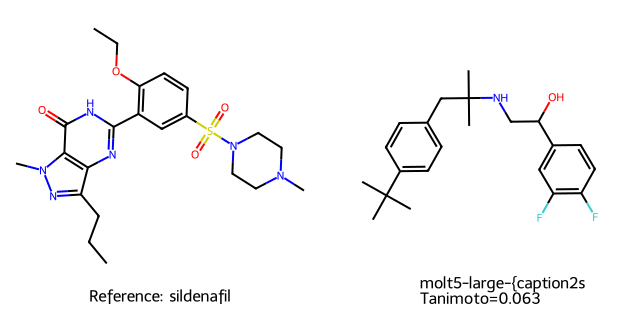

In [15]:
# --- 9-5. 생성 분자 vs 정답 나란히 보기 ---
mols, legends = [REF_MOL], ["Reference: sildenafil"]
for r in RESULTS:
    if r["SMILES 유효"] is True:
        mols.append(Chem.MolFromSmiles(r["생성 SMILES"]))
        legends.append(f"{r['세대'].split()[0]} {r['모델'].split('/')[-1][:22]}\nTanimoto={r['Tanimoto']}")

print(f"그림에 넣을 분자 {len(mols)}개 (정답 1 + 유효 생성 {len(mols) - 1})")
if len(mols) == 1:
    print("[안내] 유효한 SMILES를 생성한 세대가 없어 정답 구조만 표시합니다.")

display(Draw.MolsToGridImage(mols, legends=legends,
                             molsPerRow=min(3, len(mols)), subImgSize=(320, 320)))

### 9-6. 해석 — 무엇이 달라졌고, 무엇을 말하면 안 되는가

**세대 ① 전용 번역기의 한계 (MolT5)**

- ChEBI-20 캡션 스타일의 **구조 서술문**("벤젠 고리에 나이트로기...")에는 잘 대응하지만,
  `sildenafil` 같은 **고유명사·약리작용 서술**은 학습 분포 밖입니다. 이름을 키로 DB를 조회하는 모델이 아닙니다.
- 방향마다 **별도 체크포인트**가 필요합니다(caption2smiles / smiles2caption). 하나의 모델에게 "이번엔 반대로 해줘"라고 말할 수 없습니다.
- 출력에 **신뢰도 표시가 없습니다.** 7절에서 실데나필을 다른 약효군으로 설명해도 모델은 똑같이 단정적으로 말합니다.

**세대 ② 지시학습 LLM이 더하는 것 (ChemDFM · ChemLLM)**

- 하나의 모델이 **양방향 + 그 밖의 태스크**(물성 질의, 반응, 명명법)를 대화로 처리합니다.
- 중간 추론을 **말로 풀어 쓰기** 때문에 어디서 틀렸는지 사람이 짚을 수 있습니다. 전용 번역기는 문자열 하나만 뱉습니다.
- 대신 **모델이 커지고**(8B, 16GB), 라이선스 제약(ChemDFM은 AGPL-3.0)과 배포 비용이 붙습니다.

**세대 ③ 멀티모달 · 프론티어**

- `ChemVLM-8B` 는 **구조 이미지**를 직접 입력받습니다 — 스캔한 특허 도면, 논문 Figure가 곧 입력이 됩니다.
- 상용 프론티어(Gemini/GPT-5)는 화학 전용 학습을 하지 않고도 유명 약물에 대해서는 사실상 **암기+추론**으로 답합니다.
  이건 강점인 동시에, **잘 알려지지 않은 신규 골격에서는 급격히 무너질 수 있다**는 뜻이기도 합니다.

---

> ### ⚠️ 이 비교의 한계 — 반드시 같이 기억할 것
>
> **이것은 벤치마크가 아니라 시연입니다.**
>
> - 분자 **1개**, 문제 **2개**입니다. n=1 결과로 모델 우열을 말할 수 없습니다.
> - 실데나필은 **너무 유명한 약**입니다. 프론티어 LLM에게는 사실상 암기 문제이고, MolT5에게는 분포 밖 문제입니다.
>   즉 이 문제 설계 자체가 세대 ③에 유리하게 기울어 있습니다.
> - 채점의 "설명 키워드"는 **문자열 포함 여부**일 뿐, 설명의 사실성 검증이 아닙니다.
> - 제대로 된 비교라면 **ChEBI-20 / MoleculeNet / SciKnowEval** 같은 공개 벤치마크에서
>   수백~수천 샘플로 BLEU·Exact match·Validity·FCD 등을 재야 합니다.
>
> 이 절의 목적은 순위표를 만드는 게 아니라, **"모델 세대가 바뀌면 애초에 던질 수 있는 질문의 종류가 바뀐다"**
> 는 것을 한 화면에서 보는 것입니다.

**추가 참고 (모델 카드 · 논문)**

* ChemDFM: Zhao et al. (2025). *Developing ChemDFM as a large language foundation model for chemistry.*
  Cell Reports Physical Science 6(4). arXiv:2401.14818 · 모델: https://huggingface.co/OpenDFM/ChemDFM-v1.5-8B (AGPL-3.0)
* ChemLLM: https://huggingface.co/AI4Chem/ChemLLM-7B-Chat (Apache-2.0, InternLM2 기반, `trust_remote_code` 필요)
* ChemVLM: arXiv:2408.07246 · 모델: https://huggingface.co/AI4Chem/ChemVLM-8B (Apache-2.0, image-text-to-text)
* ChemMLLM / 3D-MoLM: 2026-09 기준 HF 접근 **게이팅(401)** — 실습 불가, 논문만 참고

## 10. 정리

MolT5는 텍스트와 분자 표현 간의 변환에서 뛰어난 다재다능함을 보여줍니다. 이 모델을 활용하면 화학 반응 예측, 분자 특성 추정 등의 다양한 화학정보학 작업에 적용할 수 있습니다.

다만 9절에서 직접 확인했듯이, 그 다재다능함은 **ChEBI-20 캡션 스타일의 구조 서술문**이라는 학습 분포 안에서만 성립합니다.
분포 밖 입력(고유명사·약리작용 서술)에서는 조용히 어긋난 답을 내놓으므로, 출력은 언제나 RDKit 파싱과 문헌 대조로 검증해야 합니다.

## 11. 참고문헌

* **MolT5 논문**: Edwards, C., Lai, T., Ros, K., Honke, G., Cho, K., & Ji, H. (2022).
  *Translation between Molecules and Natural Language.* EMNLP 2022. arXiv:2204.11817.
  코드/데이터: https://github.com/blender-nlp/MolT5
* **T5 아키텍처**: Raffel, C., Shazeer, N., Roberts, A., et al. (2020).
  *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer.* Journal of Machine Learning Research, 21(140), 1-67.
* **관련 분자 NLP 모델**: Schwaller, P., Laino, T., Gaudin, T., et al. (2019).
  *Molecular Transformer: A Model for Uncertainty-Calibrated Chemical Reaction Prediction.* ACS Central Science, 5(9), 1572-1583.
* **모델 카드**: https://huggingface.co/laituan245/molt5-large-caption2smiles ,
  https://huggingface.co/laituan245/molt5-large-smiles2caption
* **세대 ②·③ 모델 카드/논문**: 9-6절 하단의 "추가 참고" 목록 참조.

## 12. 한계와 주의

- **MolT5는 데이터베이스가 아니다.** "설명 → SMILES"를 학습한 번역 모델일 뿐이므로,
  `sildenafil` 같은 고유명사를 넣어도 실제 구조가 나오지 않는 경우가 대부분이다 (4절에서 직접 확인).
- **방향마다 체크포인트가 따로 필요하고, 신뢰도 표시가 없다.** 7절처럼 설명이 실제 약리작용과 어긋나도
  모델은 똑같이 단정적으로 말한다. 출력은 항상 RDKit 파싱 + 문헌 대조로 재검증해야 한다.
- **RDKit 파싱 통과 ≠ 쓸모 있는 분자.** 문법적으로 유효한 SMILES라도 합성 가능성·안정성·활성은 전혀 보장되지 않는다.
- **9절 세대 비교는 벤치마크가 아니라 시연이다.** 분자 1개 · 문제 2개(n=1)이고, 실데나필이라는
  지나치게 유명한 약을 골랐기 때문에 애초에 프론티어 모델에 유리하게 기울어 있다 (9-6절 참조).
- **실행 환경에 따라 결과 표의 행 수가 달라진다.** 세대 ②는 GPU가, 세대 ③은 API 키가 없으면 자동으로
  건너뛰며, 건너뛴 세대는 0점이 아니라 `SKIP` 으로 남는다. 표를 인용할 때 이 사실을 함께 밝혀야 한다.

## 13. 다음 실습

6일차의 나머지 노트북으로 이어진다.

- [`t050_simple-local-rag.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t050_simple-local-rag.ipynb)
  — 여기서 본 "생성 결과를 검증한다"는 문제의식을 **문헌 근거 기반 생성(RAG)** 으로 확장한다.
  PDE5 논문 8편을 검색 가능한 지식 베이스로 만들고, 출처가 붙은 답변을 받는다.
- `nb1_scientific_agent.ipynb` — 모델을 대화 상대가 아니라 **도구를 실행하는 워커(에이전트)** 로 쓰는 실습.
  MolT5가 혼자 못 하던 "실제 DB 조회"를 도구 호출로 해결한다.
- `qwen_tcga_advanced_2024.ipynb` — 사전학습 모델을 **내 데이터에 맞춰 정렬 학습(ORPO/DPO)** 하는 실습.
  9절에서 본 세대 ② 지시학습 LLM을 직접 만들어 보는 단계다.